In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
pd.options.display.max_colwidth = 2000
pd.set_option('display.float_format', lambda x: f'{x:.5f}'.rstrip('0').rstrip('.'))

In [3]:
df = pd.read_parquet('merged_dataset.parquet')

In [4]:
display(df.info())
print('duplicate rows: ', df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 878503 entries, 0 to 878502
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Date                         878503 non-null  str    
 1   Time                         878503 non-null  str    
 2   Item Code                    878503 non-null  int64  
 3   Quantity Sold (kilo)         878503 non-null  float64
 4   Unit Selling Price (RMB/kg)  878503 non-null  float64
 5   Sale or Return               878503 non-null  str    
 6   Discount (Yes/No)            878503 non-null  str    
 7   Item Name                    878503 non-null  str    
 8   Category Code                878503 non-null  int64  
 9   Category Name                878503 non-null  str    
 10  Loss Rate (%)                878503 non-null  float64
 11  Wholesale Price (RMB/kg)     878503 non-null  float64
dtypes: float64(4), int64(2), str(6)
memory usage: 131.0 MB


None

duplicate rows:  0


In [5]:
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'],format='mixed')

df = df.drop(columns=['Date', 'Time'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 878503 entries, 0 to 878502
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   Item Code                    878503 non-null  int64         
 1   Quantity Sold (kilo)         878503 non-null  float64       
 2   Unit Selling Price (RMB/kg)  878503 non-null  float64       
 3   Sale or Return               878503 non-null  str           
 4   Discount (Yes/No)            878503 non-null  str           
 5   Item Name                    878503 non-null  str           
 6   Category Code                878503 non-null  int64         
 7   Category Name                878503 non-null  str           
 8   Loss Rate (%)                878503 non-null  float64       
 9   Wholesale Price (RMB/kg)     878503 non-null  float64       
 10  Datetime                     878503 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(4), int

In [6]:
col_order = ['Item Code','Datetime', 'Quantity Sold (kilo)', 'Unit Selling Price (RMB/kg)',
             'Sale or Return', 'Discount (Yes/No)','Item Name', 'Category Code',
             'Category Name', 'Loss Rate (%)', 'Wholesale Price (RMB/kg)']
df = df[col_order]
df.head()

,Item Code,Datetime,Quantity Sold (kilo),Unit Selling Price (RMB/kg),Sale or Return,Discount (Yes/No),Item Name,Category Code,Category Name,Loss Rate (%),Wholesale Price (RMB/kg)
0,102900005117056,2020-07-01 09:15:07.924,0.396,7.6,sale,No,Paopaojiao (Jingpin),1011010504,Capsicum,7.08,4.32
1,102900005115960,2020-07-01 09:17:27.295,0.849,3.2,sale,No,Chinese Cabbage,1011010101,Flower/Leaf Vegetables,22.27,2.1
2,102900005117056,2020-07-01 09:17:33.905,0.409,7.6,sale,No,Paopaojiao (Jingpin),1011010504,Capsicum,7.08,4.32
3,102900005115823,2020-07-01 09:19:45.450,0.421,10,sale,No,Shanghaiqing,1011010101,Flower/Leaf Vegetables,14.43,7.03
4,102900005115908,2020-07-01 09:20:23.686,0.539,8,sale,No,Caixin,1011010101,Flower/Leaf Vegetables,13.7,4.6


In [7]:
df.describe()

,Item Code,Datetime,Quantity Sold (kilo),Unit Selling Price (RMB/kg),Category Code,Loss Rate (%),Wholesale Price (RMB/kg)
count,878503,878503,878503,878503,878503,878503,878503
mean,103031278328503.29688,2021-11-21 11:06:38.618934,0.53611,8.91714,1011010365.0721,10.12253,5.66315
min,102900005115168,2020-07-01 09:15:07.924000,-9.082,0.1,1011010101,0,0.01
25%,102900005116257,2021-02-06 11:08:54.420000,0.29,4.9,1011010101,6.27,3
50%,102900005118817,2021-10-11 10:15:24.514000,0.435,7.9,1011010402,9.43,4.69
75%,102900011016701,2022-09-10 10:35:24.490500,0.742,10.8,1011010504,13.62,7.01
max,106973990980123,2023-06-30 21:40:48.248000,160,119.9,1011010801,29.25,141
std,717436816050.83667,NaN,0.40009,6.31127,258.29287,4.74144,4.22964


In [8]:
df['Sale or Return'].value_counts()

Sale or Return
sale      878042
return       461
Name: count, dtype: int64

In [9]:
df[(df['Sale or Return'] == 'sale') & (df['Quantity Sold (kilo)'] < 0)]

,Item Code,Datetime,Quantity Sold (kilo),Unit Selling Price (RMB/kg),Sale or Return,Discount (Yes/No),Item Name,Category Code,Category Name,Loss Rate (%),Wholesale Price (RMB/kg)


### Summary of Data
The dataset consists of 878,503 transactions with 11 features related to sales, pricing, and product categories. Key insights include:

- No missing values in any column, ensuring data completeness.
- Duplicate transactions were not found, confirming data integrity.
- Category & Transaction: "Flower/Leaf Vegetables" is the most frequent product category, and "sale" is the most common transaction type.
- Pricing & Sales: The average unit selling price is 8.92 RMB/kg.
- Wholesale & Loss: The average wholesale price is 5.66 RMB/kg, with an average product loss rate of 10.12%.
- Transaction Trends: Significantly more sales records (878,042) than return records (461) shape the customer purchase behavior.
- Quantity Distribution: Quantities sold per transaction range from -9.08 kg to 160 kg, with an average purchase weight of 0.54 kg.
- This dataset is well-structured for exploratory data analysis, inventory optimization, and sales forecasting.

In [10]:
sales = df[df['Sale or Return']=='sale']
returns = df[df['Sale or Return']=='return']

In [11]:
sales['amount'] = sales['Quantity Sold (kilo)'] * sales['Unit Selling Price (RMB/kg)']
sales['cost'] = (sales['Quantity Sold (kilo)'] / (1 - sales['Loss Rate (%)'] / 100)) * sales['Wholesale Price (RMB/kg)']
sales['profit'] = sales['amount'] - sales['cost']

- In fresh products sale, all inventry doesnt get utilized cause its perishable, a lot of inventory is loss cause products get spoiled, thus there is a standard loss rate calculated for it from historical data this is also accounted as cost for product, this while calculating the cost, we must account for loss rate.

In [12]:
total_revenue = sales['amount'].sum()
total_profit = sales['profit'].sum()
overall_margin = (total_profit / total_revenue) * 100
total_volume = sales['Quantity Sold (kilo)'].sum()

print(f"Total Revenue : {total_revenue:,.2f} RMB")
print(f"Total Net Profit: {total_profit:,.2f} RMB")
print(f"Overall Profit Margin: {overall_margin:.2f}%")
print(f"Total Volume Sold: {total_volume:,.2f} kg")

Total Revenue : 3,372,023.34 RMB
Total Net Profit: 1,004,734.89 RMB
Overall Profit Margin: 29.80%
Total Volume Sold: 471,275.84 kg


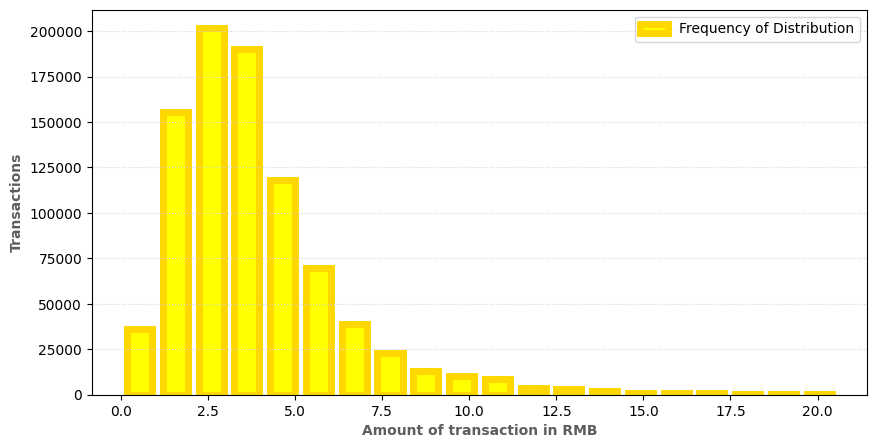

In [13]:
plt.figure(figsize=(10,5))
plt.hist(sales.loc[sales['amount'].
    between(sales['amount'].quantile(0),sales['amount'].quantile(0.999)),'amount'],
    bins=20,rwidth=.7,
    color='yellow',edgecolor='gold',linewidth=5,label='Frequency of Distribution')
plt.grid(axis='y',ls=':',c='lightgrey')
plt.xlabel('Amount of transaction in RMB',color='#5d5d5d',weight='bold')
plt.ylabel('Transactions',weight='bold',color='#5d5d5d')
plt.legend()
plt.show()


**Key Insights from Transaction Amount Distribution (0–0.999 quintile)**  

- The majority of transactions fall between **2.0–4.0 RMB**, with the peak around **2.5 RMB** (~200,000 transactions).  
- Transaction frequency declines steadily as the amount increases beyond 4 RMB.  
- Very few transactions occur at higher amounts (above 10 RMB), showing that small-value purchases dominate.  
- The distribution is heavily skewed toward **low-value transactions**, highlighting that most customer activity is concentrated in micro-purchases.  

In [14]:

sales.groupby('Category Name')['Quantity Sold (kilo)'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).round(2).astype(str)+'Kg'

,count,mean,std,min,25%,50%,75%,90%,99%,max
Category Name,,,,,,,,,,
Aquatic Tuberous Vegetables,58613.0Kg,0.69Kg,0.55Kg,0.05Kg,0.37Kg,0.56Kg,0.97Kg,1.12Kg,2.41Kg,17.0Kg
Cabbage,86524.0Kg,0.48Kg,0.2Kg,0.02Kg,0.36Kg,0.44Kg,0.56Kg,0.74Kg,1.14Kg,12.49Kg
Capsicum,207894.0Kg,0.44Kg,0.31Kg,0.0Kg,0.22Kg,0.34Kg,0.57Kg,1.0Kg,1.0Kg,10.01Kg
Edible Mushroom,148341.0Kg,0.51Kg,0.37Kg,0.01Kg,0.22Kg,0.35Kg,1.0Kg,1.0Kg,1.0Kg,25.0Kg
Flower/Leaf Vegetables,331789.0Kg,0.6Kg,0.46Kg,0.0Kg,0.34Kg,0.49Kg,0.89Kg,1.0Kg,1.73Kg,160.0Kg
Solanum,44881.0Kg,0.5Kg,0.23Kg,0.05Kg,0.35Kg,0.46Kg,0.59Kg,0.77Kg,1.29Kg,12.5Kg


#### Monthly trend of sales/revenue, profit, profit margin and frequency of transactions

In [15]:
sales['Year_Month'] = sales['Datetime'].dt.to_period('M')

monthly_trends = sales.groupby('Year_Month').agg(
    Transactions=('Quantity Sold (kilo)', 'count'),
    Total_Kilos_Sold=('Quantity Sold (kilo)', 'sum'),
    Total_Revenue_RMB=('amount', 'sum'),
    Total_Profit_RMB=('profit', 'sum')
).reset_index()

monthly_trends['Net_Margin_Pct'] = (monthly_trends['Total_Profit_RMB'] / monthly_trends['Total_Revenue_RMB']) * 100
monthly_trends.head()

,Year_Month,Transactions,Total_Kilos_Sold,Total_Revenue_RMB,Total_Profit_RMB,Net_Margin_Pct
0,2020-07,33559,13642.358,122761.2647,39953.32776,32.54555
1,2020-08,36577,15475.786,133932.0319,40895.42388,30.53446
2,2020-09,28148,12113.76,106561.182,33293.00733,31.24309
3,2020-10,31876,15069.882,122721.6468,37666.82144,30.69289
4,2020-11,28034,14979.328,84608.6888,24019.35536,28.38876


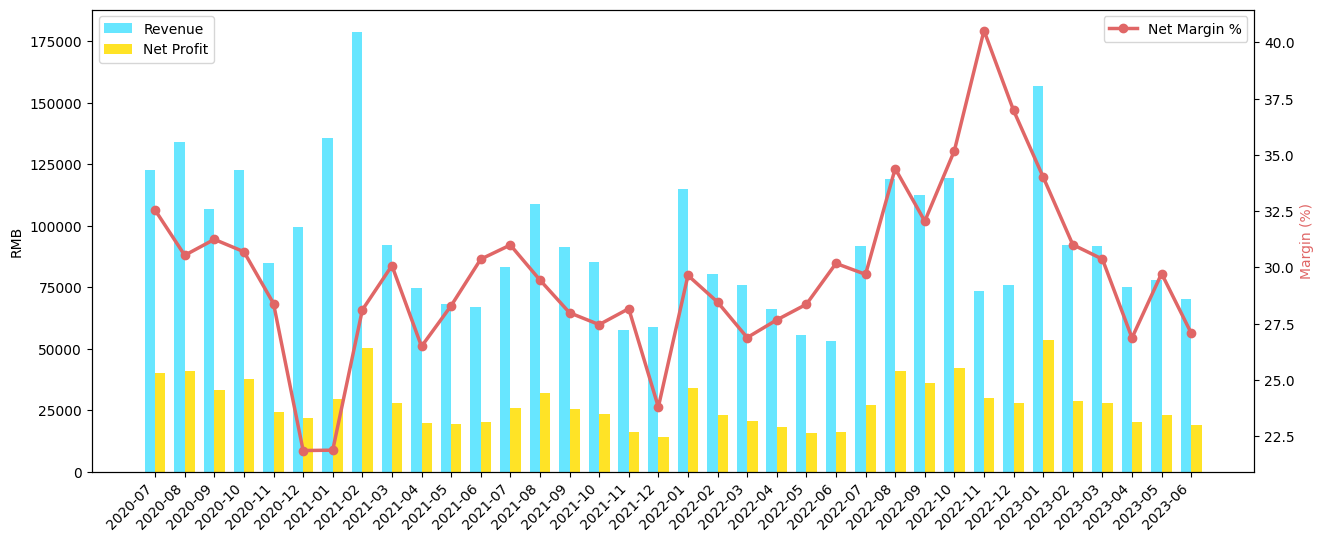

In [16]:
df_macro = monthly_trends.copy()
df_macro['Year_Month_Str'] = df_macro['Year_Month'].astype(str)

fig, ax1 = plt.subplots(figsize=(15, 6))
x = np.arange(len(df_macro))
width = 0.35

ax1.bar(x - width/2, df_macro['Total_Revenue_RMB'], width, label='Revenue', color='#67e6ff')
ax1.bar(x + width/2, df_macro['Total_Profit_RMB'], width, label='Net Profit', color='#ffe326')
ax1.set_ylabel('RMB')
ax1.set_xticks(x)
ax1.set_xticklabels(df_macro['Year_Month_Str'], rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(x, df_macro['Net_Margin_Pct'], color='#e06666', marker='o', lw=2.5, label='Net Margin %')
ax2.set_ylabel('Margin (%)', color='#e06666')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

- Revenue growth: Sales generally increase over time, but with clear seasonal peaks and dips. This reflects demand cycles for fresh items (festivals, harvest seasons, or weather-driven demand).

- Profit volatility: Net profit doesn’t always rise in proportion to revenue. Some months show strong sales but weak profit, likely due to higher costs or wastage.

- Margin fluctuations:

    Margin drops → Revenue is high but costs eat into profit.

    Margin spikes → Efficient inventory management, reduced wastage, or premium pricing.

#### MOM and  YOY growth %

In [17]:
monthly_growth = sales.groupby('Year_Month').agg(
    Total_Revenue_RMB=('amount', 'sum'),
    Total_Profit_RMB=('profit', 'sum'),
    Total_Volume_KG=('Quantity Sold (kilo)', 'sum')
).sort_index().reset_index()

monthly_growth['Revenue_MoM_%'] = monthly_growth['Total_Revenue_RMB'].pct_change(1) * 100
monthly_growth['Profit_MoM_%'] = monthly_growth['Total_Profit_RMB'].pct_change(1) * 100
monthly_growth['Revenue_YoY_%'] = monthly_growth['Total_Revenue_RMB'].pct_change(12) * 100
monthly_growth['Profit_YoY_%'] = monthly_growth['Total_Profit_RMB'].pct_change(12) * 100

monthly_growth[['Year_Month', 'Total_Revenue_RMB', 'Revenue_MoM_%', 'Revenue_YoY_%', 'Total_Profit_RMB', 'Profit_MoM_%', 'Profit_YoY_%']]


,Year_Month,Total_Revenue_RMB,Revenue_MoM_%,Revenue_YoY_%,Total_Profit_RMB,Profit_MoM_%,Profit_YoY_%
0,2020-07,122761.2647,NaN,NaN,39953.32776,NaN,NaN
1,2020-08,133932.0319,9.09959,NaN,40895.42388,2.35799,NaN
2,2020-09,106561.182,-20.43637,NaN,33293.00733,-18.5899,NaN
3,2020-10,122721.6468,15.16543,NaN,37666.82144,13.13734,NaN
4,2020-11,84608.6888,-31.05643,NaN,24019.35536,-36.23206,NaN
5,2020-12,99426.0633,17.51283,NaN,21727.64564,-9.5411,NaN
6,2021-01,135749.835,36.53345,NaN,29687.34702,36.63398,NaN
7,2021-02,178876.1668,31.76898,NaN,50274.24158,69.34569,NaN
8,2021-03,92141.1032,-48.48889,NaN,27712.21111,-44.87791,NaN
9,2021-04,74642.2614,-18.99135,NaN,19768.11767,-28.6664,NaN


### Summary of revenue, sales volume, profit, profit margin average loss rate category wise

In [18]:
category_summary = sales.groupby('Category Name').agg(
    Volume_Sold_KG=('Quantity Sold (kilo)', 'sum'),
    Total_Revenue_RMB=('amount', 'sum'),
    Total_Profit_RMB=('profit', 'sum'),
    Avg_Loss_Rate_Pct=('Loss Rate (%)', 'mean')
).reset_index()

category_summary['Profit_Margin_Pct'] = (category_summary['Total_Profit_RMB'] / category_summary['Total_Revenue_RMB']) * 100
category_summary.sort_values(by='Total_Profit_RMB', ascending=False)

,Category Name,Volume_Sold_KG,Total_Revenue_RMB,Total_Profit_RMB,Avg_Loss_Rate_Pct,Profit_Margin_Pct
4,Flower/Leaf Vegetables,198659.553,1079834.829,336679.63285,12.73453,31.17881
2,Capsicum,91645.112,754564.4229,238458.63086,7.75568,31.60216
3,Edible Mushroom,76131.726,620110.202,184641.3048,8.88363,29.77556
1,Cabbage,41789.777,375980.8439,102096.69916,10.66528,27.15476
0,Aquatic Tuberous Vegetables,40607.552,350306.0611,81757.36694,8.91174,23.33884
5,Solanum,22442.119,191226.9834,61101.25673,6.41216,31.95221


**Key Insights**  

- **High-volume but high-loss:**  
  Flower/Leaf Vegetables drive the largest sales and revenue, but spoilage is significant (12.7%), which erodes efficiency.  

- **High-margin performers:**  
  Capsicum and Solanum deliver the strongest profit margins (≈31–32%) with relatively low loss rates. These are the most efficient categories.  

- **Moderate contributors:**  
  Edible Mushrooms and Cabbage generate solid revenue but face spoilage challenges (≈9–11%), keeping margins below 30%.  

- **Weakest profitability:**  
  Aquatic Tuberous Vegetables show the lowest margin (23.3%), making them the least efficient despite decent sales volume.  

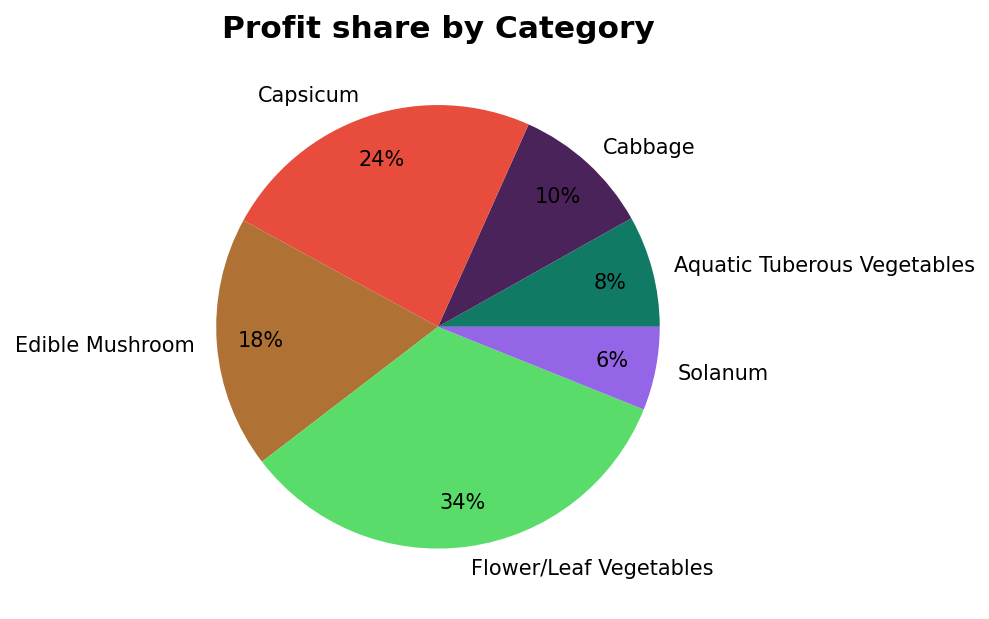

In [19]:
plt.figure(dpi=150)
pie_color = ['#117A65','#4A235A','#E74C3C','#af7134','#59dc69','#9565e8']
plt.pie(x=category_summary['Total_Profit_RMB'],
        labels=category_summary['Category Name'],
        autopct='%.0f%%',
        pctdistance=0.8,
        labeldistance=1.1,
        colors=pie_color
)

plt.title('Profit share by Category',fontsize=15,weight=700)
plt.show()

### Summary of sales volume, profit, profit margin average loss rate item wise
- top 10 profit making products
- top 10 loss making product

In [20]:
item_summary = sales.groupby('Item Name').agg(
    Total_Profit=('profit', 'sum'),
    Total_Volume=('Quantity Sold (kilo)', 'sum'),
    Avg_Loss_Rate=('Loss Rate (%)', 'first')
).sort_values(by='Total_Profit', ascending=False)

display(item_summary.head(10))
display(item_summary.tail(10))

,Total_Profit,Total_Volume,Avg_Loss_Rate
Item Name,,,
Broccoli,71842.16404,27556.616,9.26
Net Lotus Root (1),53614.71377,27166.459,5.54
Wuhu Green Pepper (1),52732.60037,28181.741,5.7
Xixia Mushroom (1),49098.14303,11929.1,13.82
Yunnan Shengcai,35631.75217,15915.422,15.25
Eggplant (2),35132.36953,13608.976,6.07
Millet Pepper (Bag),24467.77454,10847,9.43
Luosi Pepper,22093.62843,7794.899,10.18
Yunnan Lettuces,21615.36602,10309.079,12.81


,Total_Profit,Total_Volume,Avg_Loss_Rate
Item Name,,,
Fruit Pepper (Orange),1.54282,0.415,9.43
White Jelly Mushroom,1.52428,1,11.13
Big Broccoli,-6.4012,7.48,4.69
Huanghuacai,-7.3234,1.784,16.89
Round Eggplant (1),-8.14183,4.981,9.43
Caidian Quinoa Artemisia (Bag),-13.48401,65,9.43
Chicken Fir Bacteria,-18.26975,1.215,11.93
Hongshan Caitai,-54.92676,25,9.34
Hongshan Shoutidai,-176,3,0


#### Calculation of profit contribution of each item percentage wise and cumulative profit percentage to plot paretos plot

In [21]:
item_shares = sales.groupby('Item Name')['profit'].sum().reset_index().sort_values(by='profit', ascending=False)
item_shares['Profit_Contribution_Pct'] = (item_shares['profit'] / item_shares['profit'].sum()) * 100
item_shares['Cumulative_Profit_Pct'] = item_shares['Profit_Contribution_Pct'].cumsum()
item_shares.head(15)

,Item Name,profit,Profit_Contribution_Pct,Cumulative_Profit_Pct
24,Broccoli,71842.16404,7.15036,7.15036
136,Net Lotus Root (1),53614.71377,5.33621,12.48657
209,Wuhu Green Pepper (1),52732.60037,5.24841,17.73497
223,Xixia Mushroom (1),49098.14303,4.88668,22.62165
233,Yunnan Shengcai,35631.75217,3.54638,26.16803
45,Eggplant (2),35132.36953,3.49668,29.66472
120,Millet Pepper (Bag),24467.77454,2.43525,32.09996
114,Luosi Pepper,22093.62843,2.19895,34.29891
232,Yunnan Lettuces,21615.36602,2.15135,36.45026
231,Yunnan Lettuce (Bag),21578.31131,2.14766,38.59793


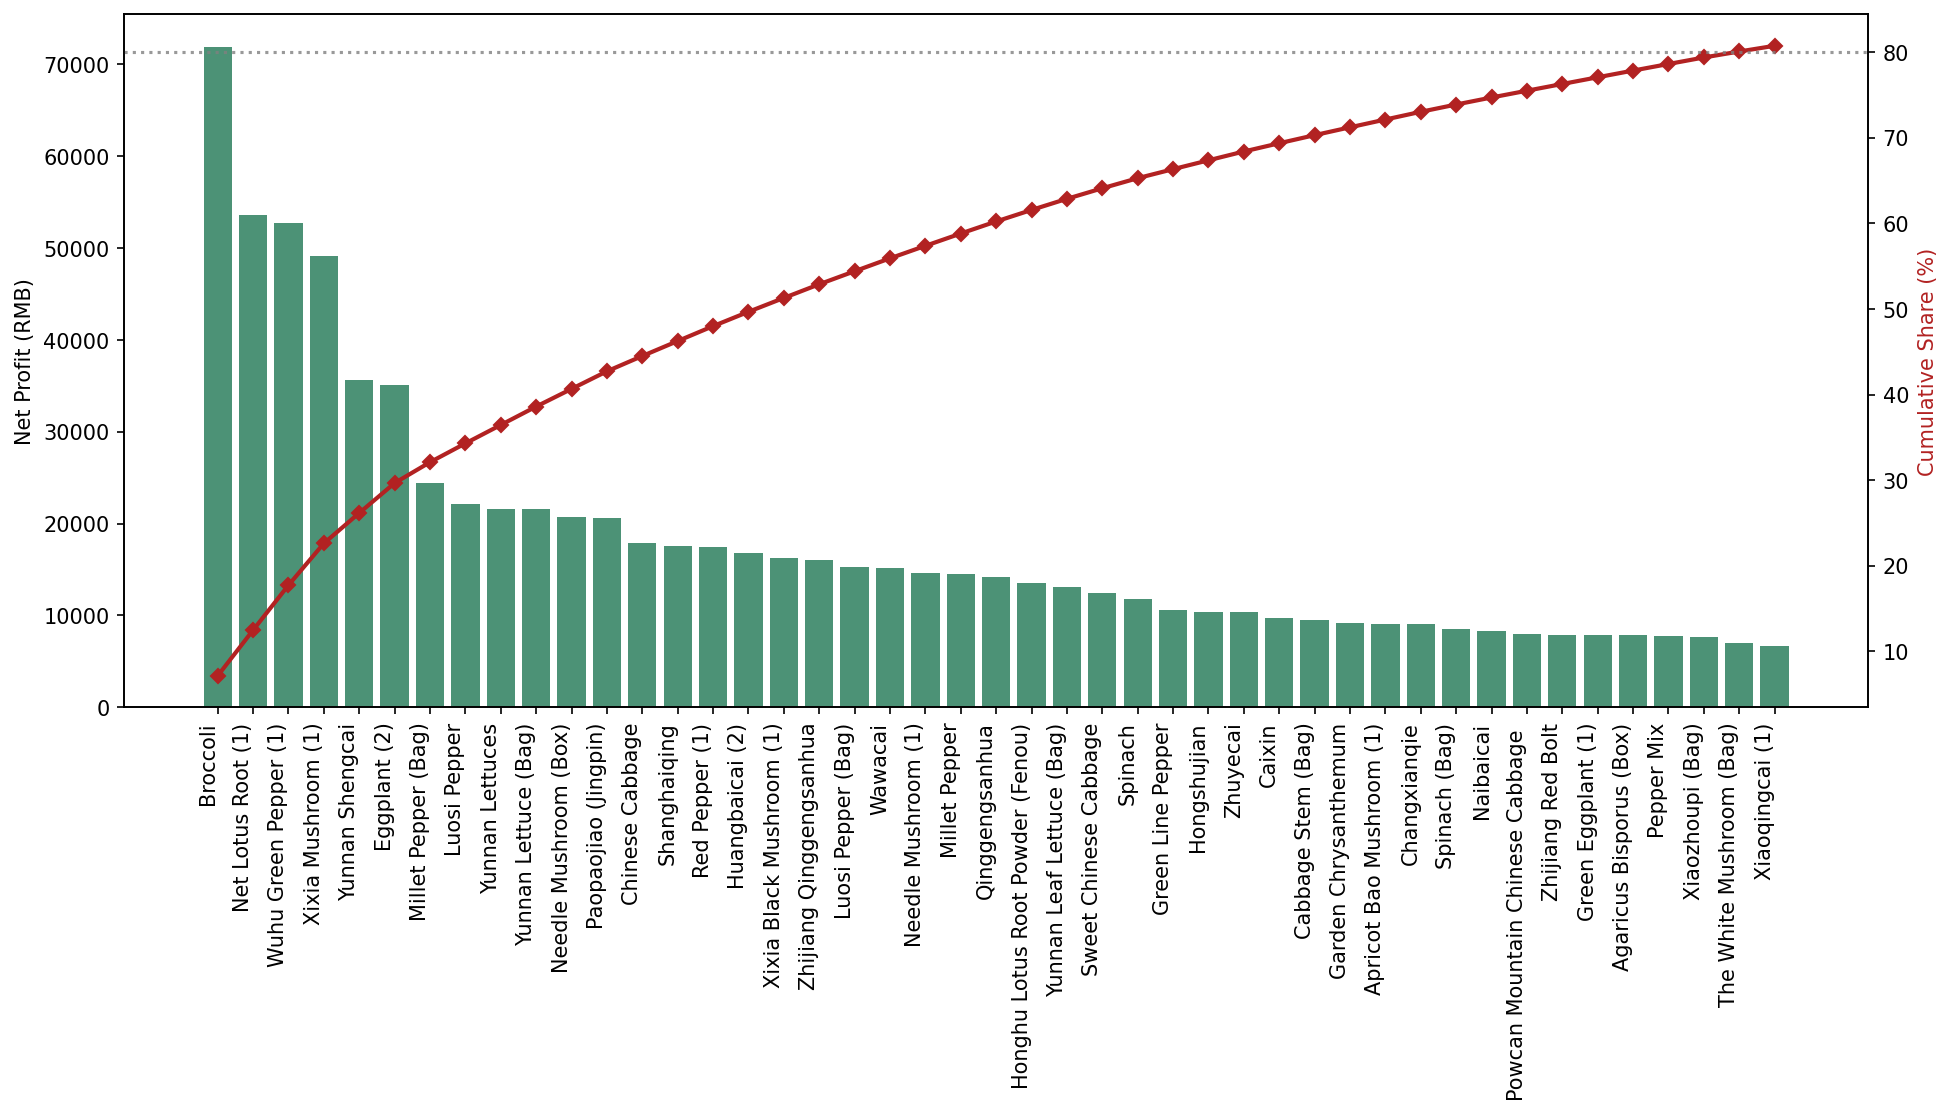

In [22]:
df_pareto = item_shares.head(45)

fig, ax1 = plt.subplots(figsize=(15, 6),dpi=150)
ax1.bar(df_pareto['Item Name'], df_pareto['profit'], color='#2d7f5e', alpha=0.85)
ax1.set_ylabel('Net Profit (RMB)')
ax1.set_xticks(range(len(df_pareto)))
ax1.set_xticklabels(df_pareto['Item Name'], rotation=90, ha='right')

ax2 = ax1.twinx()
ax2.plot(df_pareto['Item Name'], df_pareto['Cumulative_Profit_Pct'], color='#b22222', marker='D', ms=5, lw=2)
ax2.set_ylabel('Cumulative Share (%)', color='#b22222')
ax2.axhline(80, color='gray', linestyle=':', alpha=0.8)
plt.show()


- *Broccoli* is the single largest profit contributor, far ahead of other items.  
- A small group of items (Broccoli, Lotus Root, Green Pepper, Xixia Mushroom, Lettuce) together account for the majority of total profit.  
- Profitability is highly concentrated — the top categories quickly accumulate most of the share, showing a Pareto effect.  
- Beyond the first dozen items, contributions drop sharply, with many categories adding only marginal profit.  
- The chart highlights that a few vegetables dominate overall profitability, while the long tail of items has limited impact.  

In [23]:
portfolio = sales.groupby(['Category Name', 'Item Name']).agg(
    Total_Kilos_Sold=('Quantity Sold (kilo)', 'sum'),
    Total_Revenue_RMB=('amount', 'sum'),
    Total_Profit_RMB=('profit', 'sum')
).reset_index()

portfolio['Margin_Pct'] = (portfolio['Total_Profit_RMB'] / portfolio['Total_Revenue_RMB']) * 100
vol_cutoff = portfolio['Total_Kilos_Sold'].median()
margin_cutoff = portfolio['Margin_Pct'].median()

display(
    portfolio.head(),
    vol_cutoff,
    margin_cutoff
    
)

,Category Name,Item Name,Total_Kilos_Sold,Total_Revenue_RMB,Total_Profit_RMB,Margin_Pct
0,Aquatic Tuberous Vegetables,Fresh Lotus Root Zone (Bag),21,388.2,27.41658,7.06249
1,Aquatic Tuberous Vegetables,High Melon (1),1179.956,16266.7647,2599.42348,15.97997
2,Aquatic Tuberous Vegetables,High Melon (2),449.856,8969.1363,2181.51168,24.32243
3,Aquatic Tuberous Vegetables,Honghu Lotus (Lotus Root),40,395.2,26.97653,6.82604
4,Aquatic Tuberous Vegetables,Honghu Lotus Root,745.554,21463.0442,2169.61224,10.1086


np.float64(251.0)

np.float64(33.16309036769924)

High revenue can hide poor profitability if the net margin is too low. To evaluate performance accurately, we will categorize items into a standard $2 \times 2$ matrix using the dataset's median transaction volume and median profit margin as split points.Star: 
- High Volume, High Margin (Top performers driving both cash and returns)
- Cash Cow: High Volume, Low Margin (High rotation items with lower profitability)
- Niche: Low Volume, High Margin (Low rotation items with high profitability per unit)
- Underperformer: Low Volume, Low Margin (Inefficient items dragging down portfolio performance)

In [24]:
def segmenting_inventory(row):
    high_vol = row['Total_Kilos_Sold'] >= vol_cutoff
    high_margin = row['Margin_Pct'] >= margin_cutoff
    if high_vol and high_margin: return 'Star'
    if high_vol and not high_margin: return 'Cash Cow'
    if not high_vol and high_margin: return 'Niche'
    return 'Underperformer'

portfolio['Inventory_Quadrant'] = portfolio.apply(segmenting_inventory, axis=1)

display(portfolio['Inventory_Quadrant'].value_counts())
portfolio[portfolio['Inventory_Quadrant'] == 'Underperformer'].head(15)

Inventory_Quadrant
Star              67
Underperformer    66
Cash Cow          55
Niche             55
Name: count, dtype: int64

,Category Name,Item Name,Total_Kilos_Sold,Total_Revenue_RMB,Total_Profit_RMB,Margin_Pct,Inventory_Quadrant
0,Aquatic Tuberous Vegetables,Fresh Lotus Root Zone (Bag),21,388.2,27.41658,7.06249,Underperformer
3,Aquatic Tuberous Vegetables,Honghu Lotus (Lotus Root),40,395.2,26.97653,6.82604,Underperformer
7,Aquatic Tuberous Vegetables,Lotus Root Tip,18.614,74.456,19.86912,26.68572,Underperformer
9,Aquatic Tuberous Vegetables,Net Lotus Root (2),62.221,371.0292,95.08283,25.62678,Underperformer
11,Aquatic Tuberous Vegetables,Red Lotus Root Zone,100.69,1075.5408,255.87755,23.79059,Underperformer
13,Aquatic Tuberous Vegetables,Water Chestnut (Bag),10,59,14.9236,25.29423,Underperformer
14,Aquatic Tuberous Vegetables,Water Chestnut (Lingjiao),126.422,1762.1858,473.98881,26.89778,Underperformer
17,Aquatic Tuberous Vegetables,Wild Pink Lotus Root,50.815,734.56,177.93631,24.22352,Underperformer
19,Cabbage,Purple Cabbage (1),13.251,180.2526,45.80377,25.41088,Underperformer
20,Cabbage,Purple Cabbage (2),0.615,9.024,2.35454,26.09198,Underperformer


In [25]:
quadrant_summary = portfolio.groupby('Inventory_Quadrant').agg(
    Unique_Item_Count=('Item Name', 'count'),
    Total_Kilos_Moved=('Total_Kilos_Sold', 'sum'),
    Total_Revenue_RMB=('Total_Revenue_RMB', 'sum'),
    Total_Profit_RMB=('Total_Profit_RMB', 'sum')
).reset_index()

total_store_profit = portfolio['Total_Profit_RMB'].sum()
quadrant_summary['Profit_Share_Pct'] = (quadrant_summary['Total_Profit_RMB'] / total_store_profit) * 100

display(quadrant_summary.sort_values(by='Total_Profit_RMB', ascending=False))

,Inventory_Quadrant,Unique_Item_Count,Total_Kilos_Moved,Total_Revenue_RMB,Total_Profit_RMB,Profit_Share_Pct
0,Cash Cow,55,278076.187,2269471.9422,592181.12439,58.93904
2,Star,67,188068.269,1053553.8489,396343.33125,39.44755
1,Niche,55,3250.036,31732.2181,12635.9252,1.25764
3,Underperformer,66,1881.347,17265.3331,3574.51051,0.35577


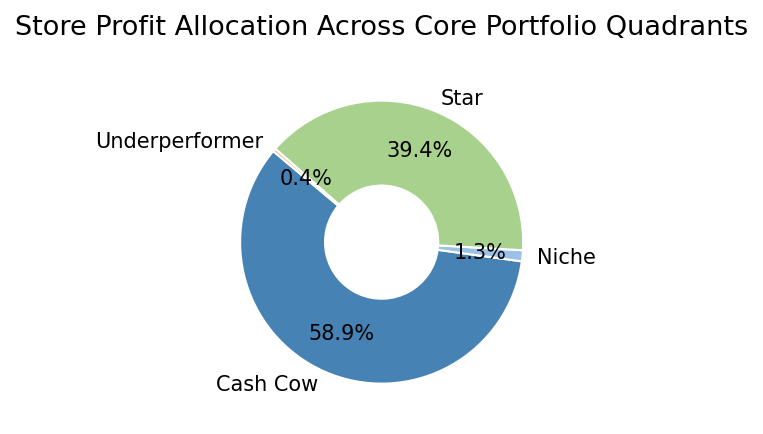

In [26]:
plt.figure(figsize=(4,3),dpi=150)

quadrant_colors = ['#4682b4', '#9bc2e6', '#a9d18e', '#f4b183']

plt.pie(quadrant_summary['Profit_Share_Pct'], 
        labels=quadrant_summary['Inventory_Quadrant'], 
        autopct='%1.1f%%', 
        pctdistance=0.7,
        startangle=140, 
        colors=quadrant_colors, 
        wedgeprops=dict(width=0.6, edgecolor='w'))
plt.title('Store Profit Allocation Across Core Portfolio Quadrants', fontsize=13, pad=15)
plt.tight_layout()
plt.show()


**Key Insights from Quadrant Table**  

- **Cash Cow** → Largest driver with **55 items**, moving ≈278K kilos, generating ≈2.27M RMB revenue and ≈592K RMB profit. Accounts for **58.9% of total profit**.  
- **Star** → Strong contributor with **67 items**, ≈188K kilos moved, ≈1.05M RMB revenue, ≈396K RMB profit. Represents **39.4% of profit**.  
- **Niche** → Smaller scale with **55 items**, only ≈3.2K kilos moved, ≈31.7K RMB revenue, ≈12.6K RMB profit. Contributes **1.3% of profit**.  
- **Underperformer** → **66 items**, ≈1.9K kilos moved, ≈17.3K RMB revenue, ≈3.6K RMB profit. Minimal impact at **0.36% of profit**.  

In [27]:
item_longevity = sales.groupby(['Category Name', 'Item Name']).agg(
    Months_Active=('Year_Month', 'nunique'),
    Total_Kilos=('Quantity Sold (kilo)', 'sum'),
    Total_Profit=('profit', 'sum')
).reset_index().sort_values(by='Months_Active')

display(item_longevity[item_longevity['Months_Active'] <= 3].head(15)) # availabe for less than 3 months in period of 3 years
display(item_longevity[item_longevity['Months_Active'] >= 30].tail(15)) # available and in demand for whole year 

,Category Name,Item Name,Months_Active,Total_Kilos,Total_Profit
0,Aquatic Tuberous Vegetables,Fresh Lotus Root Zone (Bag),1,21,27.41658
9,Aquatic Tuberous Vegetables,Net Lotus Root (2),1,62.221,95.08283
13,Aquatic Tuberous Vegetables,Water Chestnut (Bag),1,10,14.9236
16,Aquatic Tuberous Vegetables,Wild Lotus Root (2),1,11.398,95.60038
31,Capsicum,Fruit Pepper (Orange),1,0.415,1.54282
28,Capsicum,Bell Pepper (Bag),1,6,4.2222
20,Cabbage,Purple Cabbage (2),1,0.615,2.35454
49,Capsicum,Purple Hot Peppers,1,1.754,2.88437
98,Edible Mushroom,Hfyg Haixian Mushroom (Bunch),1,109,57.9968
106,Edible Mushroom,Needle Mushroom (Bag),1,1,3.38959


,Category Name,Item Name,Months_Active,Total_Kilos,Total_Profit
224,Flower/Leaf Vegetables,Yunnan Lettuces,32,10309.079,21615.36602
202,Flower/Leaf Vegetables,Spinach,33,5218.388,11830.80023
209,Flower/Leaf Vegetables,Wawacai,33,9002,15159.93897
124,Edible Mushroom,The White Mushroom (Bag),33,2927,7025.75882
132,Edible Mushroom,Xixia Mushroom (1),33,11929.1,49098.14303
146,Flower/Leaf Vegetables,Caixin,34,4498.148,9712.88879
166,Flower/Leaf Vegetables,Huangbaicai (2),34,7993.683,16830.49391
43,Capsicum,Luosi Pepper,35,7794.899,22093.62843
225,Flower/Leaf Vegetables,Yunnan Shengcai,35,15915.422,35631.75217
237,Solanum,Green Eggplant (1),35,3519.011,7882.37389


In [28]:
sales['Day_of_Week'] = sales['Datetime'].dt.dayofweek
sales['Day_Name'] = sales['Datetime'].dt.day_name()

weekly_trends = sales.groupby(['Day_of_Week', 'Day_Name']).agg(
    Total_Volume_KG=('Quantity Sold (kilo)', 'sum'),
    Total_Revenue_RMB=('amount', 'sum'),
    Transaction_Count=('Quantity Sold (kilo)', 'count')
).reset_index().drop(columns='Day_of_Week')

weekly_trends

,Day_Name,Total_Volume_KG,Total_Revenue_RMB,Transaction_Count
0,Monday,60485.879,425469.8475,112892
1,Tuesday,58288.114,419046.9608,109648
2,Wednesday,59400.835,435787.0921,111950
3,Thursday,58348.906,413592.2775,108226
4,Friday,66205.723,471285.7386,120944
5,Saturday,85791.596,609718.8377,158841
6,Sunday,82754.786,597122.5881,155541


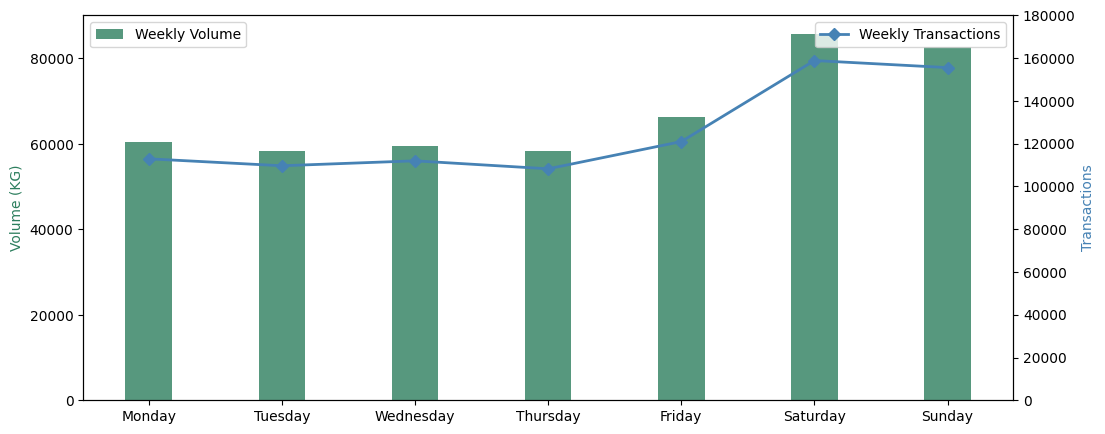

In [29]:
df_weekly = weekly_trends.copy()
fig, ax1 = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_weekly))
width = 0.35

ax1.bar(x , df_weekly['Total_Volume_KG'], width, color='#2d7f5e', alpha=0.8,label='Weekly Volume')
ax1.set_ylabel('Volume (KG)', color='#2d7f5e')
ax1.set_xticks(x)
ax1.set_xticklabels(df_weekly['Day_Name'])
ax1.legend()

ax2 = ax1.twinx()
ax2.plot(x, df_weekly['Transaction_Count'], color='#4682b4', marker='D', lw=2,label='Weekly Transactions')
ax2.set_ylabel('Transactions', color='#4682b4')
ax2.set_ylim(0, 180000)
ax2.legend()
plt.show()

**Key Insights from Weekly Volume & Transactions Chart**  

- Both **volume (kg)** and **transactions** rise steadily through the week.  
- Activity is **lowest on Monday–Tuesday**, showing weaker demand at the start of the week.  
- Midweek (Wednesday–Friday) shows a **gradual increase**, indicating growing customer flow.  
- **Saturday and Sunday peak** in both metrics, confirming weekends as the busiest period for sales and customer transactions.  
- The strong correlation between volume and transactions suggests that higher customer traffic directly drives higher product movement.  

In [30]:
sales['Hour'] = sales['Datetime'].dt.hour
hourly_trend = sales.groupby('Hour').agg(
    Transaction_Count=('Quantity Sold (kilo)', 'count'),
    Total_Volume_KG=('Quantity Sold (kilo)', 'sum'),
    Total_Revenue_RMB=('amount', 'sum')
).reset_index()

hourly_trend

,Hour,Transaction_Count,Total_Volume_KG,Total_Revenue_RMB
0,8,1,0.391,3.91
1,9,74028,39365.279,281636.4498
2,10,120882,64175.632,468556.1935
3,11,94702,50393.723,368231.319
4,12,49147,26405.52,192970.5383
5,13,35568,19305.986,142960.7967
6,14,41765,22880.365,169298.6804
7,15,62078,33436.247,247330.9091
8,16,82722,43998.522,320429.8181
9,17,92751,49008.163,352846.3385


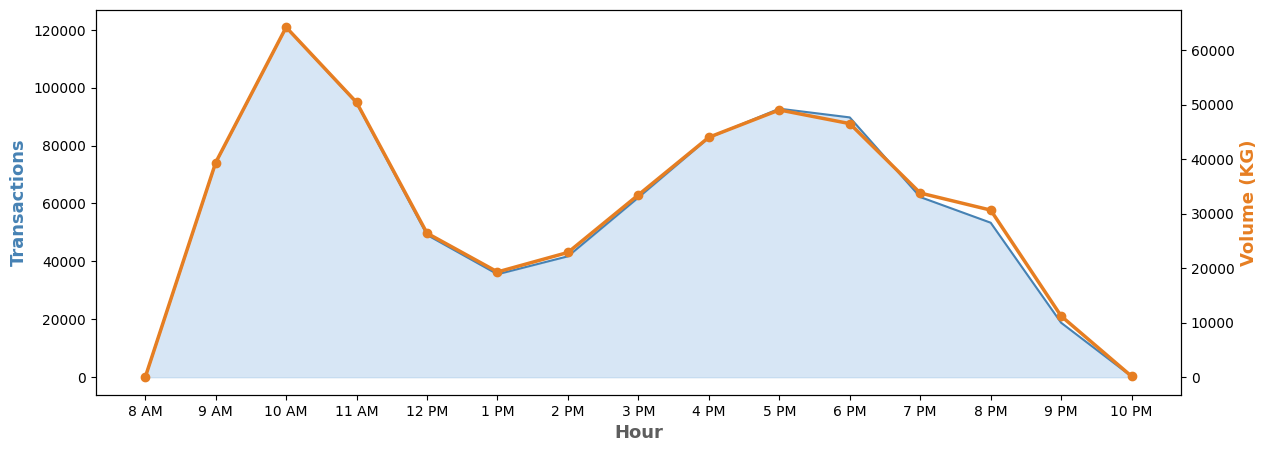

In [31]:
hour_labels = [
    pd.to_datetime(f"{h}:00", format="%H:%M").strftime("%I %p").lstrip('0') 
    for h in hourly_trend['Hour']
]


fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.fill_between(hourly_trend['Hour'], hourly_trend['Transaction_Count'], color='#9bc2e6', alpha=0.4)
ax1.plot(hourly_trend['Hour'], hourly_trend['Transaction_Count'], color='#4682b4', lw=1.5)
ax1.set_ylabel('Transactions', color='#4682b4',fontsize=13,weight='bold')
ax1.set_xlabel('Hour',fontsize=13,weight='bold',color='#5d5d5d')
ax1.set_xticks(hourly_trend['Hour'])
ax1.set_xticklabels(hour_labels)

ax2 = ax1.twinx()
ax2.plot(hourly_trend['Hour'], hourly_trend['Total_Volume_KG'], color='#e67e22', marker='o', lw=2.5)
ax2.set_ylabel('Volume (KG)', color='#e67e22',fontsize=13,weight='bold')

plt.show()

**Key Insights from Hourly Transactions & Volume Chart**  

- **Morning peak:** Both transactions and volume surge around **10 AM**, marking the strongest activity window.  
- **Midday dip:** Activity declines around **12–2 PM**, showing reduced customer flow and product movement.  
- **Afternoon recovery:** Between **3–6 PM**, transactions and volume rise again, forming a secondary peak.  
- **Evening slowdown:** After **6 PM**, both metrics gradually decline toward closing hours (10 PM).  
- **Pattern correlation:** Transaction frequency and volume move closely together, highlighting synchronized demand cycles across the day.  

In [32]:
peak_hours = sales[sales['Hour'].isin([9, 10, 11, 18, 19, 20])].copy()
peak_hours['Time_of_Day'] = peak_hours['Hour'].apply(lambda x: 'Morning' if x in [9, 10, 11] else 'Evening')
display(peak_hours[:2])
hourly_mix = peak_hours.groupby(['Category Name', 'Time_of_Day'])['Quantity Sold (kilo)'].sum().unstack()
display(hourly_mix[:2])
hourly_mix_pct = hourly_mix.div (hourly_mix.sum(axis=0), axis=1) * 100
hourly_mix_pct = hourly_mix_pct.round(2).reset_index()
hourly_mix_pct

,Item Code,Datetime,Quantity Sold (kilo),Unit Selling Price (RMB/kg),Sale or Return,Discount (Yes/No),Item Name,Category Code,Category Name,Loss Rate (%),Wholesale Price (RMB/kg),amount,cost,profit,Year_Month,Day_of_Week,Day_Name,Hour,Time_of_Day
0,102900005117056,2020-07-01 09:15:07.924,0.396,7.6,sale,No,Paopaojiao (Jingpin),1011010504,Capsicum,7.08,4.32,3.0096,1.84107,1.16853,2020-07,2,Wednesday,9,Morning
1,102900005115960,2020-07-01 09:17:27.295,0.849,3.2,sale,No,Chinese Cabbage,1011010101,Flower/Leaf Vegetables,22.27,2.1,2.7168,2.29371,0.42309,2020-07,2,Wednesday,9,Morning


Time_of_Day,Evening,Morning
Category Name,,
Aquatic Tuberous Vegetables,5574.627,17642.813
Cabbage,10035.03,13371.597


Time_of_Day,Category Name,Evening,Morning
0,Aquatic Tuberous Vegetables,5.03,11.46
1,Cabbage,9.05,8.69
2,Capsicum,21.37,17.09
3,Edible Mushroom,17.8,13.77
4,Flower/Leaf Vegetables,41.39,44.62
5,Solanum,5.37,4.37


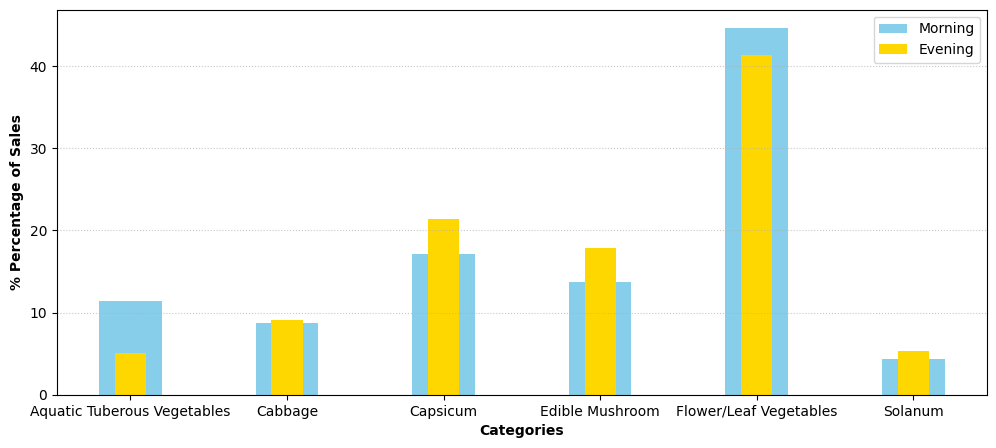

In [33]:
plt.figure(figsize=(12,5))
plt.bar(hourly_mix_pct['Category Name'],hourly_mix_pct['Morning'],
        label='Morning',width=.4,color='skyblue')
plt.xlabel('Categories',fontsize=10,weight='bold')
plt.bar(hourly_mix_pct['Category Name'],hourly_mix_pct['Evening'],
        label='Evening',width=.2,color='gold')
plt.ylabel('% Percentage of Sales',fontsize=10,weight='bold')
plt.grid(axis='y',alpha=.7,ls=':') 

plt.legend() 
plt.show()

**Key Insights from Morning vs Evening Sales Chart**  

- **Flower/Leaf Vegetables** → Highest share of sales in both morning and evening, showing consistent demand throughout the day.  
- **Capsicum & Edible Mushroom** → Balanced sales across morning and evening, with moderate contribution.  
- **Cabbage** → Slightly stronger in evening sales compared to morning.  
- **Aquatic Tuberous Vegetables** → Lower overall share, but evening sales are marginally higher.  
- **Solanum** → Lowest sales percentage in both morning and evening, indicating weak demand relative to other categories.  


### 2. Pricing Resilience: Wholesale Volatility & Spoilage
Fresh produce rots, and wholesale prices fluctuate. If we calculate margins based strictly on the base wholesale price, we are lying to ourselves. 

First, let's look at how volatile the wholesale costs are across categories.

In [34]:
sales.groupby('Category Name')['Wholesale Price (RMB/kg)'].agg(
    Min_Wholesale='min',
    Max_Wholesale='max',
    Volatility_Idx=lambda x: (x.std() / x.mean()).round(4) * 100
).sort_values(by='Volatility_Idx', ascending=False)

,Min_Wholesale,Max_Wholesale,Volatility_Idx
Category Name,,,
Capsicum,0.04,53.24,83.44
Flower/Leaf Vegetables,0.01,141,71.38
Edible Mushroom,0.1,80,61.21
Aquatic Tuberous Vegetables,0.01,38.78,54.76
Solanum,0.01,15.82,40.04
Cabbage,0.01,14.38,32.06


**Key Insights from Wholesale Price & Volatility Table**  

- **Capsicum** → Very wide price range (0.04–53.24 RMB) and highest volatility index (**83.44**), indicating strong price fluctuations.  
- **Flower/Leaf Vegetables** → Largest price span (0.01–141 RMB) with high volatility (**71.38**), showing unstable pricing.  
- **Edible Mushroom** → Moderate range (0.1–80 RMB) and volatility (**61.21**), reflecting medium instability.  
- **Aquatic Tuberous Vegetables** → Narrower range (0.01–38.78 RMB) and lower volatility (**54.76**) compared to mushrooms.  
- **Solanum** → Small price range (0.01–15.82 RMB) and relatively low volatility (**40.04**).  
- **Cabbage** → Tightest price band (0.01–14.38 RMB) and lowest volatility index (**32.06**), making it the most stable category.  

#### Calculating True Unit Cost
Now we adjust our costs. We will calculate the **True Unit Cost** by mathematically factoring the `Loss Rate (%)` into the wholesale price. By comparing the `Raw_Spread` to the `Adjusted_Spread`, we can see our actual profit buffer per kilo.

In [35]:
item_spreads = sales.groupby(['Category Name', 'Item Name']).agg(
    Base_Wholesale=('Wholesale Price (RMB/kg)', 'mean'),
    Loss_Rate=('Loss Rate (%)','first'),
    Base_Retail=('Unit Selling Price (RMB/kg)', 'mean')
).reset_index()

item_spreads['True_Unit_Cost'] = item_spreads['Base_Wholesale'] / (1 - item_spreads['Loss_Rate'] / 100)
item_spreads['Raw_Spread'] = item_spreads['Base_Retail'] - item_spreads['Base_Wholesale']
item_spreads['Adjusted_Spread'] = item_spreads['Base_Retail'] - item_spreads['True_Unit_Cost']

category_spreads = item_spreads.groupby('Category Name').agg(
    Median_Raw_Markup=('Raw_Spread', 'median'),
    Median_Adjusted_Markup=('Adjusted_Spread', 'median')
).sort_values(by='Median_Adjusted_Markup', ascending=False)

display(category_spreads.round(2))
item_spreads.sort_values(by='Adjusted_Spread',ascending=False).head(10).round(2) # products with best Adjusted markup/kg 

,Median_Raw_Markup,Median_Adjusted_Markup
Category Name,,
Capsicum,4.32,3.81
Solanum,3.4,2.92
Cabbage,3.31,2.72
Edible Mushroom,3.21,2.6
Aquatic Tuberous Vegetables,3.31,2.24
Flower/Leaf Vegetables,2.6,2.04


,Category Name,Item Name,Base_Wholesale,Loss_Rate,Base_Retail,True_Unit_Cost,Raw_Spread,Adjusted_Spread
72,Edible Mushroom,Black Chicken Mushroom,63.19,11.03,104.89,71.02,41.71,33.87
81,Edible Mushroom,Chopped Red Pine,12,8.75,25.8,13.15,13.8,12.65
48,Capsicum,Pepper Mix,2.4,9.43,14.67,2.65,12.27,12.02
178,Flower/Leaf Vegetables,Malan Head,30.22,15.16,47.05,35.62,16.83,11.43
120,Edible Mushroom,The Steak Mushrooms,15.74,8.11,28.36,17.13,12.62,11.23
78,Edible Mushroom,Chinese Caterpillar Fungus Flowers,16.06,11.68,28.88,18.19,12.82,10.69
36,Capsicum,Green Hangjiao (1),7.6,0,17.48,7.6,9.88,9.88
156,Flower/Leaf Vegetables,Ganlanye,2,11.58,12,2.26,10,9.74
24,Capsicum,7 Colour Pepper (2),13.03,9.43,24.04,14.39,11,9.65
45,Capsicum,Millet Pepper,16.05,5.86,26.58,17.05,10.53,9.53


**Key Insights from Median Markup Table**  

- **Capsicum** → Highest markup values (Raw: 4.32, Adjusted: 3.81), showing strong pricing power.  
- **Solanum** → Moderate markup (Raw: 3.4, Adjusted: 2.92), slightly above average.  
- **Cabbage** → Raw markup 3.31, Adjusted 2.72, reflecting stable but modest margins.  
- **Edible Mushroom** → Raw 3.21, Adjusted 2.6, positioned in the mid-range.  
- **Aquatic Tuberous Vegetables** → Raw 3.31, Adjusted 2.24, showing a sharper reduction after adjustment.  
- **Flower/Leaf Vegetables** → Lowest markup (Raw: 2.6, Adjusted: 2.04), indicating weaker margin leverage compared to other categories.  


In [36]:
monthly_margin_drift = sales.groupby('Year_Month').agg(
    Avg_Retail=('amount', lambda x: x.sum() / sales.loc[x.index, 'Quantity Sold (kilo)'].sum()),
    Avg_Wholesale=('Wholesale Price (RMB/kg)', lambda x: (x * sales.loc[x.index, 'Quantity Sold (kilo)']).sum() / sales.loc[x.index, 'Quantity Sold (kilo)'].sum()),
    Avg_True_Cost=('cost', lambda x: x.sum() / sales.loc[x.index, 'Quantity Sold (kilo)'].sum())
).reset_index()

monthly_margin_drift['Raw_Spread'] = monthly_margin_drift['Avg_Retail'] - monthly_margin_drift['Avg_Wholesale']
monthly_margin_drift['Adjusted_Spread'] = monthly_margin_drift['Avg_Retail'] - monthly_margin_drift['Avg_True_Cost']

monthly_margin_drift[['Year_Month', 'Raw_Spread', 'Adjusted_Spread']]

,Year_Month,Raw_Spread,Adjusted_Spread
0,2020-07,3.60036,2.92862
1,2020-08,3.31557,2.64254
2,2020-09,3.40346,2.74836
3,2020-10,3.1077,2.49948
4,2020-11,2.01928,1.6035
5,2020-12,1.9468,1.41532
6,2021-01,2.72181,1.9709
7,2021-02,3.55709,2.8553
8,2021-03,2.76006,2.2034
9,2021-04,2.40787,1.83419


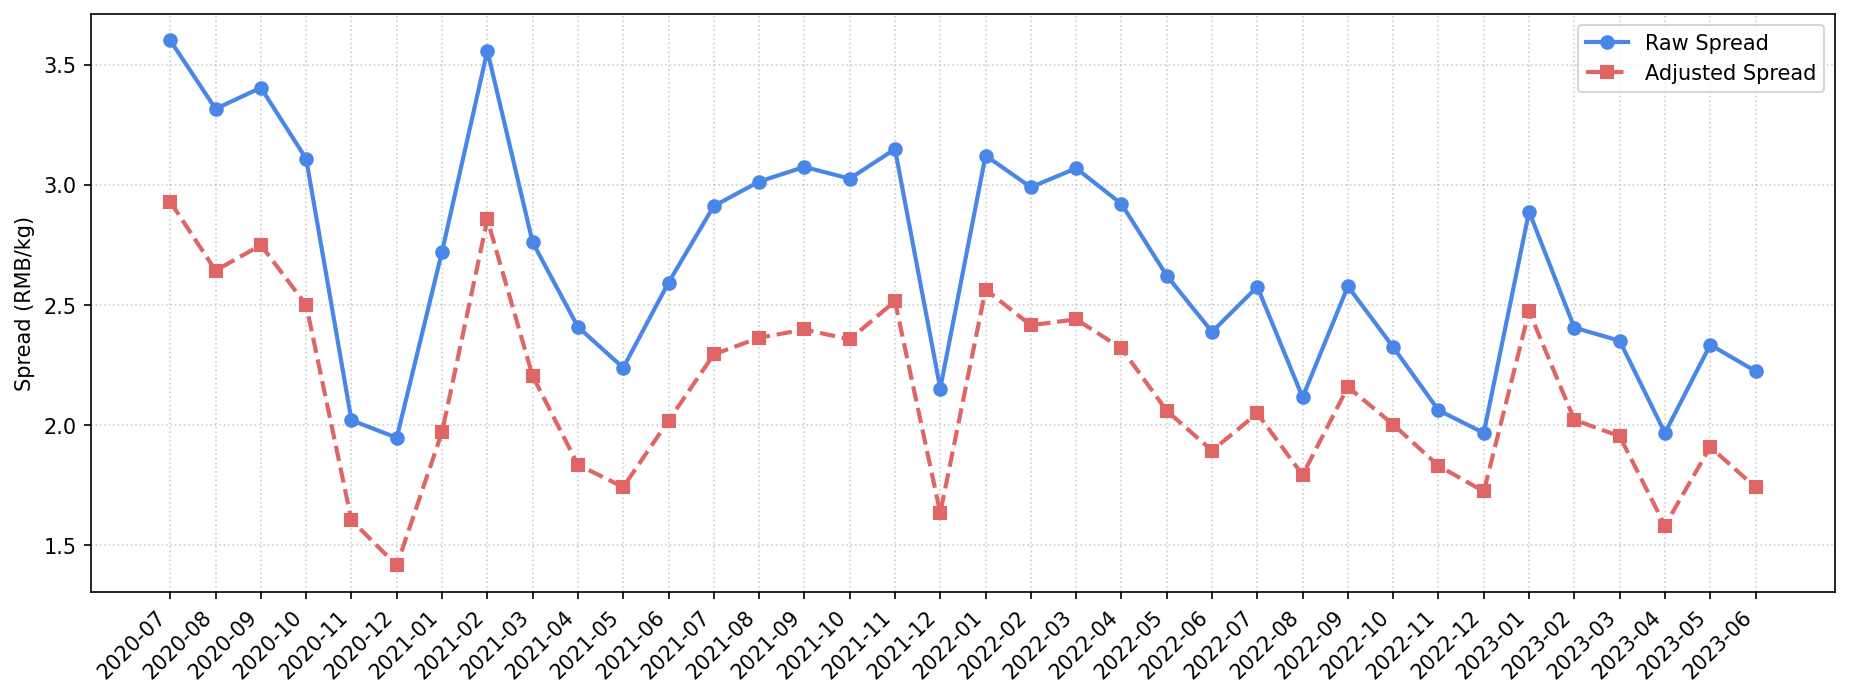

In [37]:
df_drift = monthly_margin_drift.copy()
df_drift['Year_Month_Str'] = df_drift['Year_Month'].astype(str)

plt.figure(figsize=(15, 5),dpi=150)
plt.plot(df_drift['Year_Month_Str'], df_drift['Raw_Spread'], color='#4a86e8', marker='o', lw=2, label='Raw Spread')
plt.plot(df_drift['Year_Month_Str'], df_drift['Adjusted_Spread'], color='#e06666', marker='s', lw=2, ls='--', label='Adjusted Spread')
plt.ylabel('Spread (RMB/kg)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, ls=':', alpha=0.6)
plt.legend()
plt.show()

In [38]:

risk_pricing = sales.groupby(['Category Name', 'Item Name']).agg(
    Loss_Rate=('Loss Rate (%)', 'first'),
    Avg_Wholesale=('Wholesale Price (RMB/kg)', 'mean'),
    Avg_Retail=('Unit Selling Price (RMB/kg)', 'mean')
).reset_index()

risk_pricing['Markup_Pct'] = ((risk_pricing['Avg_Retail'] - risk_pricing['Avg_Wholesale']) / risk_pricing['Avg_Wholesale']) * 100

risk_metrics = risk_pricing.groupby('Category Name').agg(
    Item_Count=('Item Name', 'count'),
    Avg_Loss_Rate=('Loss_Rate', 'mean'),
    Avg_Markup_Pct=('Markup_Pct', 'mean'),
    Risk_Correlation=('Loss_Rate', lambda x: x.corr(risk_pricing.loc[x.index, 'Markup_Pct']))
).sort_values(by='Risk_Correlation', ascending=False)

risk_metrics

,Item_Count,Avg_Loss_Rate,Avg_Markup_Pct,Risk_Correlation
Category Name,,,,
Cabbage,5,14.142,58.40848,0.68676
Flower/Leaf Vegetables,98,10.30592,70.45188,0.15057
Capsicum,43,8.48791,80.15536,0.07204
Edible Mushroom,69,8.03826,118.32484,0.06351
Aquatic Tuberous Vegetables,18,11.78889,59.11902,0.0342
Solanum,10,7.122,73.05649,-0.53894


**Key Insights from risk_metrics**  
* **The Good (+0.69):** Cabbage safely defenses its bottom line by scaling prices alongside spoilage.
* **The Bad (-0.54):** Solanum flips the logic completely—items that rot faster are priced with lower margins, creating an unmitigated margin leak.
* **The Rest (~0.00):** Over 220 items across Mushrooms, Capsicum, and Leafy Greens bypass internal risk metrics entirely, meaning their prices are dictated purely by arbitrary flat rates.

In [39]:
sales['Date_Only'] = sales['Datetime'].dt.date

daily_prices = sales.groupby(['Date_Only', 'Category Name', 'Item Name']).agg(
    Wholesale_Price=('Wholesale Price (RMB/kg)', 'mean'),
    Retail_Price=('Unit Selling Price (RMB/kg)', 'mean')
).reset_index().sort_values(['Category Name', 'Item Name', 'Date_Only'])

daily_prices['Wholesale_Shift'] = daily_prices.groupby(['Category Name', 'Item Name'])['Wholesale_Price'].diff()
daily_prices['Retail_Shift'] = daily_prices.groupby(['Category Name', 'Item Name'])['Retail_Price'].diff()
#display(daily_prices)
daily_prices['Wholesale_Changed'] = (daily_prices['Wholesale_Shift'] != 0) & daily_prices['Wholesale_Shift'].notna()
daily_prices['Retail_Changed'] = (daily_prices['Retail_Shift'] != 0) & daily_prices['Retail_Shift'].notna()

price_changes = daily_prices.groupby('Category Name').agg(
    Total_Obs=('Date_Only', 'count'),
    Wholesale_Updates=('Wholesale_Changed', 'sum'),
    Retail_Updates=('Retail_Changed', 'sum')
).reset_index()

price_changes['Wholesale_Change_%'] = (price_changes['Wholesale_Updates'] / price_changes['Total_Obs']).round(4) * 100
price_changes['Retail_Change_%'] = (price_changes['Retail_Updates'] / price_changes['Total_Obs']).round(4) * 100

price_changes[['Category Name', 'Wholesale_Change_%', 'Retail_Change_%']]

,Category Name,Wholesale_Change_%,Retail_Change_%
0,Aquatic Tuberous Vegetables,60.4,32.59
1,Cabbage,86.29,41.04
2,Capsicum,82.46,38.98
3,Edible Mushroom,77.63,37.08
4,Flower/Leaf Vegetables,74.25,34.51
5,Solanum,81.85,22.67


**Key Insights from Price Update comparison**  
* **The Bottleneck (Solanum):** Wholesale costs bounce around constantly (**81.85%** of days), yet retail tags only change **22.67%** of the time. This massive lag means store prices are slow to react to market cost hikes, creating immediate margin erosion.
* **The Fluid Passer (Aquatic Tuberous):** Experiences the calmest wholesale fluctuations (**60.40%**) but features the highest conversion to retail adjustments (**0.54** ratio), keeping margins well-insulated.
* **The Labor Sinks (Cabbage & Capsicum):** Upstream prices shift almost daily (>82%). Managing these categories demands constant pricing updates just to keep pace with volatile market supply costs.

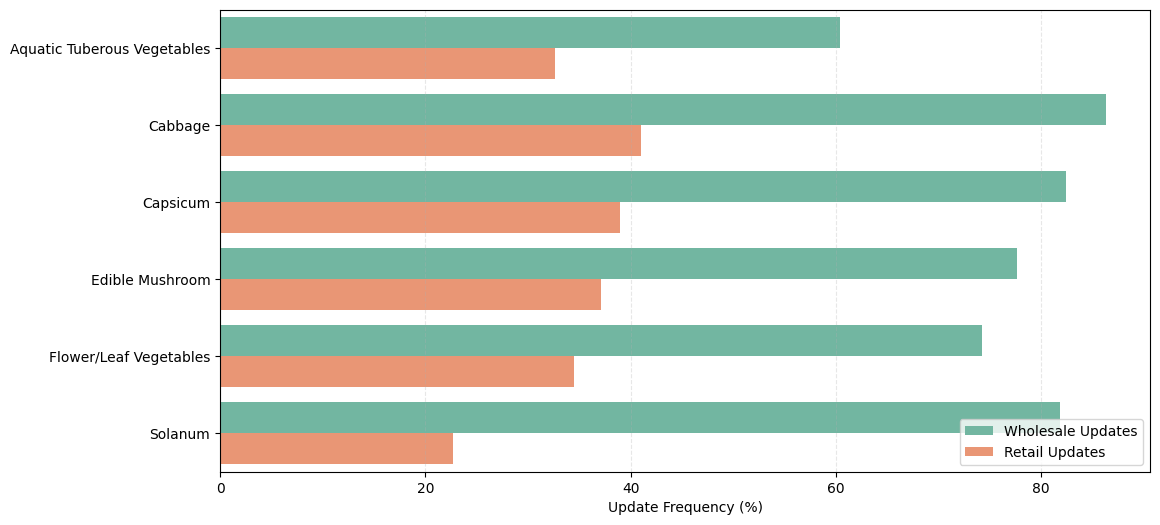

In [40]:
df_stickiness = price_changes.melt(
    id_vars='Category Name', 
    value_vars=['Wholesale_Change_%', 'Retail_Change_%'], 
    var_name='Price_Type', 
    value_name='Update_Frequency_%' 
)

df_stickiness['Price_Type'] = df_stickiness['Price_Type'].replace({
    'Wholesale_Change_%': 'Wholesale Updates', 
    'Retail_Change_%': 'Retail Updates'
})

plt.figure(figsize=(12, 6))
sns.barplot(data=df_stickiness, y='Category Name', x='Update_Frequency_%', hue='Price_Type', palette='Set2')
plt.xlabel('Update Frequency (%)')
plt.ylabel('')
plt.legend(loc='lower right')
plt.grid(axis='x', ls='--', alpha=0.3)
plt.show()

### 3. Markdown Efficacy: The Cost of Clearance

#### Clearance Strategy Hypothesis Testing
* **The Core Question:** Does the store strategically apply discounts to liquidate highly perishable stock before it spoils?
* **The Operational Condition:** Under an ideal clearance model, the store should actively markdown older inventory batches to clear the shelves while maintaining standard baseline retail pricing on fresh arrivals.
* **The Testing Methodology:** To evaluate this, we isolate instances where the exact same item is sold both with and without a discount flag within the identical hourly window on the same day (`Date_Only` + `Hour` + `Item Name`).

In [41]:

discount_check = (
    sales.groupby(['Date_Only', 'Hour', 'Item Name'])['Discount (Yes/No)']
    .agg(unique_statuses=lambda x: set(x), count='nunique')
    .reset_index()
)

overlapping_records = discount_check[discount_check['count'] == 2]
nooverlapping_records = discount_check[discount_check['count'] == 1]
print(f"Total overlapping hourly windows identified: {overlapping_records.shape[0]}")
print(f"Total non-overlapping hourly windows identified: {nooverlapping_records.shape[0]}")


Total overlapping hourly windows identified: 8285
Total non-overlapping hourly windows identified: 295756


In [42]:
display(
overlapping_records.sample(5),
nooverlapping_records[nooverlapping_records['unique_statuses']=={'Yes'}].sample(5),
nooverlapping_records[nooverlapping_records['unique_statuses']=={'No'}].sample(5)
)

,Date_Only,Hour,Item Name,unique_statuses,count
5309,2020-07-18,14,Hongshujian,"{Yes, No}",2
287904,2023-04-29,20,Xiaozhoupi (Bag),"{Yes, No}",2
5042,2020-07-17,17,Eggplant (2),"{Yes, No}",2
7329,2020-07-25,9,Qinggengsanhua,"{Yes, No}",2
3325,2020-07-12,10,Dongmenkou Xiaobaicai,"{Yes, No}",2


,Date_Only,Hour,Item Name,unique_statuses,count
288822,2023-05-02,19,Yunnan Lettuce (Bag),{Yes},1
184286,2022-04-08,20,Fruit Pepper (Bag),{Yes},1
239080,2022-10-28,20,Apricot Bao Mushroom (2),{Yes},1
138388,2021-09-24,9,Eggplant (2),{Yes},1
181819,2022-03-29,20,High Melon (2),{Yes},1


,Date_Only,Hour,Item Name,unique_statuses,count
225610,2022-09-11,10,Lotus (Ea),{No},1
86620,2021-04-05,17,Haixian Mushroom (1),{No},1
236430,2022-10-19,11,The Local Yellow Youcai,{No},1
37825,2020-10-30,17,The White Mushroom (Bag),{No},1
38549,2020-11-01,18,Yunnan Shengcai,{No},1


In [43]:
display(
nooverlapping_records[nooverlapping_records['unique_statuses']=={'Yes'}].shape[0],
nooverlapping_records[nooverlapping_records['unique_statuses']=={'No'}].shape[0]
)

11579

284177

In [44]:
sales.groupby('Discount (Yes/No)').agg(
    Avg_Selling_Price=('Unit Selling Price (RMB/kg)', 'mean'),
    Total_Volume_KG=('Quantity Sold (kilo)', 'sum'),
    Total_Profit_RMB=('profit', 'sum'),
    Avg_Margin_Pct=('profit', lambda x: (x.sum() / sales.loc[x.index, 'amount'].sum()) * 100))

,Avg_Selling_Price,Total_Volume_KG,Total_Profit_RMB,Avg_Margin_Pct
Discount (Yes/No),,,,
No,9.0257,439522.732,989028.57916,30.8023
Yes,7.01226,31753.107,15706.31218,9.74752


In [45]:
category_discount = sales.groupby(['Category Name', 'Discount (Yes/No)']).agg(
    Total_Volume_KG=('Quantity Sold (kilo)', 'sum'),
    Total_Profit_RMB=('profit', 'sum'),
    Total_Amount_RMB=('amount', 'sum')
).reset_index()

category_discount['Margin_Pct'] = (category_discount['Total_Profit_RMB'] / category_discount['Total_Amount_RMB']) * 100
category_discount.pivot(index='Category Name', columns='Discount (Yes/No)', values=['Total_Volume_KG', 'Margin_Pct'])

Total_Volume_KG           Margin_Pct         
Discount (Yes/No)                        No       Yes         No      Yes
Category Name                                                            
Aquatic Tuberous Vegetables       36957.903  3649.649    24.5794  8.52654
Cabbage                            39551.39  2238.387   28.02466  8.75984
Capsicum                          86136.785  5508.327   32.35602 10.12873
Edible Mushroom                   69782.095  6349.631   31.05742 11.40344
Flower/Leaf Vegetables           185252.452 13407.101   32.20311  8.74984
Solanum                           21842.107   600.012   32.30514  14.9331

#### Identifying the Profit Bleed
Discounting is necessary for perishables, but are we dropping prices too low? Let's isolate transactions where the retail selling price fell below the actual wholesale cost, resulting in a negative gross margin, and see which categories are bleeding the most cash.

In [46]:
sales['underpriced'] = sales['Unit Selling Price (RMB/kg)'] < sales['Wholesale Price (RMB/kg)']

sales[sales['underpriced']].groupby('Category Name').agg(
    Underpriced_Txns=('Quantity Sold (kilo)', 'count'),
    Loss_Volume=('Quantity Sold (kilo)', 'sum'),
    Total_Loss_RMB=('profit', 'sum')
).sort_values(by='Total_Loss_RMB')

,Underpriced_Txns,Loss_Volume,Total_Loss_RMB
Category Name,,,
Flower/Leaf Vegetables,4265,3295.522,-4390.49313
Capsicum,3061,1866.08,-2644.6389
Aquatic Tuberous Vegetables,1224,757.015,-2020.96879
Edible Mushroom,2969,2337.613,-1816.91616
Cabbage,872,440.772,-732.66784
Solanum,260,132.958,-153.27781


In [47]:
sales[sales['underpriced']].groupby('Hour').agg(
    Error_Count=('Quantity Sold (kilo)', 'count'),
    Total_Loss_RMB=('profit', 'sum'),
    Total_Kilos_Sold=('Quantity Sold (kilo)', 'sum')
).reset_index()

,Hour,Error_Count,Total_Loss_RMB,Total_Kilos_Sold
0,9,513,-475.65514,312.555
1,10,759,-782.71632,463.494
2,11,543,-476.83843,340.014
3,12,289,-246.88561,187.153
4,13,207,-228.125,130.745
5,14,298,-245.18708,181.424
6,15,418,-412.05829,256.839
7,16,557,-500.68986,340.651
8,17,630,-613.92645,390.792
9,18,1053,-823.0658,731.471


In [48]:
sales[sales['Hour'].isin([19, 20, 21])].groupby(['Category Name', 'underpriced']).agg(
    Kilos_Moved=('Quantity Sold (kilo)', 'sum'),
    Revenue=('amount', 'sum'),
    Profit=('profit', 'sum')
).reset_index()

,Category Name,underpriced,Kilos_Moved,Revenue,Profit
0,Aquatic Tuberous Vegetables,False,2525.473,23571.2943,5353.61354
1,Aquatic Tuberous Vegetables,True,458.467,3437.7664,-1515.30552
2,Cabbage,False,6662.682,59781.4168,15922.6152
3,Cabbage,True,265.894,1451.8503,-447.12193
4,Capsicum,False,16452.12,127796.4965,40440.53084
5,Capsicum,True,779.497,3997.7623,-1079.50715
6,Edible Mushroom,False,12109.721,91966.953,26360.24985
7,Edible Mushroom,True,1810.83,6060.0327,-1480.45111
8,Flower/Leaf Vegetables,False,28133.826,135174.8785,41172.65562
9,Flower/Leaf Vegetables,True,2117.331,6081.1288,-2375.83247


#### Clearance Velocity: Is the discount actually moving weight?
If we are going to take a massive margin hit in the evening (Hours 19, 20, 21), the discount needs to drastically increase the volume of goods moved. Let's calculate the "Clearance Ratio" to see if evening discounts actually speed up the rate of sales compared to full-price evening sales.

In [49]:
hourly_buckets = sales[sales['Hour'].isin([19, 20, 21])].groupby(
    ['Date_Only', 'Hour', 'Category Name', 'Discount (Yes/No)']
).agg(
    Kilos_In_Hour=('Quantity Sold (kilo)', 'sum'),
    Profit_In_Hour=('profit', 'sum')
).reset_index()

clearance_lift = hourly_buckets.groupby(['Category Name', 'Discount (Yes/No)']).agg(
    Hourly_Velocity_KG=('Kilos_In_Hour', 'mean'),
    Total_Profit=('Profit_In_Hour', 'sum')
).reset_index()

pivot_clearance = clearance_lift.pivot(index='Category Name', columns='Discount (Yes/No)', values=['Hourly_Velocity_KG', 'Total_Profit'])
pivot_clearance['Clearance_Ratio'] = pivot_clearance['Hourly_Velocity_KG']['Yes'] / pivot_clearance['Hourly_Velocity_KG']['No']

pivot_clearance

Hourly_Velocity_KG         Total_Profit  \
Discount (Yes/No)                           No     Yes           No   
Category Name                                                         
Aquatic Tuberous Vegetables            1.73806  1.5245   4697.59286   
Cabbage                                2.32963  1.5876  15284.69415   
Capsicum                               4.50421 3.15699  38256.45195   
Edible Mushroom                        3.38757 2.96913  24329.78027   
Flower/Leaf Vegetables                 7.11794   6.514  37031.01185   
Solanum                                1.65413 1.25757  11428.12597   

                                       Clearance_Ratio  
Discount (Yes/No)                  Yes                  
Category Name                                           
Aquatic Tuberous Vegetables -859.28485         0.87713  
Cabbage                      190.79912         0.68148  
Capsicum                    1104.57174          0.7009  
Edible Mushroom              550.01846         0.87648  
Flower/Leaf Vegetables       1765.8113         0.91515  
Solanum                      134.96472         0.76026

In [50]:
evening_basket_lift = sales[sales['Hour'].isin([19, 20, 21])].groupby(['Category Name', 'Discount (Yes/No)']).agg(
    Avg_Basket_Weight_KG=('Quantity Sold (kilo)', 'mean'),
    Txn_Count=('Quantity Sold (kilo)', 'count')
).reset_index()

evening_basket_lift.pivot(index='Category Name', columns='Discount (Yes/No)', values=['Avg_Basket_Weight_KG', 'Txn_Count'])

Avg_Basket_Weight_KG         Txn_Count      
Discount (Yes/No)                             No     Yes        No   Yes
Category Name                                                           
Aquatic Tuberous Vegetables              0.73323 0.54015      2899  1589
Cabbage                                  0.48729 0.49212     12215  1984
Capsicum                                 0.42519 0.82767     33369  3677
Edible Mushroom                          0.52481 0.65938     18661  6259
Flower/Leaf Vegetables                   0.60514  0.8905     34511 10519
Solanum                                  0.49482 0.50471      8424   299

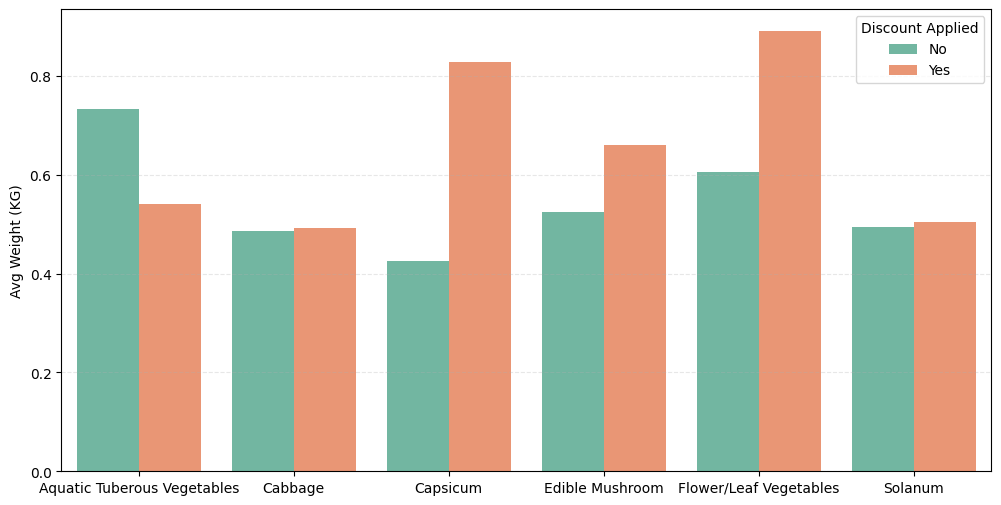

In [51]:
plt.figure(figsize=(12, 6))
sns.barplot(data=evening_basket_lift, x='Category Name', y='Avg_Basket_Weight_KG', hue='Discount (Yes/No)', palette='Set2')

plt.ylabel('Avg Weight (KG)')
plt.xlabel('')
plt.legend(title='Discount Applied')
plt.grid(axis='y', ls='--', alpha=0.3)
plt.show()

#### Hypothesis Evaluation Results
* **Total Overlapping Hourly Windows (8,285):** The presence of these windows mathematically validates the hypothesis. The store does not simply rely on scheduled, store-wide promotional events. Instead, it utilizes an active split-pricing mechanism within the same hour block for identical items, confirming that older stock batches are marked down on the fly while fresher stock remains at the baseline retail price.
* **Total Non-Overlapping Hourly Windows (295,756):** The vast majority of transaction windows show uniform pricing. Deep inspection reveals that this uniform state is overwhelmingly dominated by the standard baseline—**284,177 windows are strictly full price (`{'No'}`)**, while only **11,579 windows are uniformly discounted (`{'Yes'}`)**.

#### Financial Analysis: What Happens if the Clearance Strategy is Removed?
To evaluate the absolute baseline financial risk of eliminating this liquidation model, we isolate the performance of the **31,753.11 kg** of stock moved under the markdown flag:

1. **The Maximum Spoilage Cost Exposure (100% Waste Boundary):** If we assume that every single discounted item was at the brink of expiration and would have been thrown away completely without the markdown strategy, the store's true raw inventory cost hit is calculated by backing out the realized profit from the revenue generated:
   $$\text{Revenue} = \frac{\text{Net Profit}}{\text{Margin \%}} = \frac{15,706.31}{0.0974752} \approx 161,131.36\text{ RMB}$$
   $$\text{True Cost of Goods Sold} = 161,131.36 - 15,706.31 = \mathbf{145,425.05\text{ RMB}}$$
   *Abandoning the strategy entirely with zero sales recovery would result in a direct write-off penalty of **145,425.05 RMB** in raw product value.*

2. **The Opportunity Loss Counterfactual (Price Elasticity Realignment):**
   Assuming a 100% complete waste rate is operationally unrealistic. Downstream metrics show that the store's **Clearance Ratio is below 1.0 across all major fresh categories** (e.g., 0.91 for Leafy Greens, 0.70 for Capsicum). This proves that cutting prices failed to accelerate the hourly sales velocity ($kg/\text{hour}$). Regular evening foot traffic simply bought the items at a slower pace while absorbing a steep drop in margin rate from **30.80%** down to **9.75%**.

   If the store had skipped the markdown strategy and held the standard retail pricing benchmark of **9.03 RMB/kg** on these items:
   * **Expected Revenue at Full Price:** $31,753.11\text{ kg} \times 9.0257\text{ RMB/kg} = 286,594.02\text{ RMB}$
   * **Expected Net Profit at Baseline Margin (30.80%):** $286,594.02\text{ RMB} \times 0.308023 = 88,277.53\text{ RMB}$
   * **Actual Net Profit Realized via Markdowns:** $15,706.31\text{ RMB}$
   * **Net Strategic Drag:** $88,277.53 - 15,706.31 = \mathbf{72,571.22\text{ RMB}}$

#### Strategic Verdict
The store is bleeding cash due to severe evening pricing execution flaws. Because the markdown floor drops blindly below wholesale acquisition costs (creating thousands of negative margin errors at Hours 19–21), **the clearance strategy in its current form acts as an internal margin drain of up to 72,571.22 RMB** rather than an efficient inventory liquidation tool.